In [1]:
import numpy as np
import xarray as xr
import scipy
import astropy
import muse
from sklearn.linear_model import Ridge as Ridge
from sklearn.linear_model import LassoLars as LassoLars
from skglm import Lasso
from muse.inversions.inversions import mass_screen_gcompile
from muse.transforms.transforms import muse_fov, reshape_rs2x, reshape_x2rs
import matplotlib.pyplot as plt

# from muse.utils.sdc_benchmark import sdc_benchmark as bench
# from muse.utils.sdc_benchmark_ci_mask import sdc_benchmark as bench
import os, pdb
import matplotlib.colors as colors

In [72]:
from muse.synthesis.synthesis import (
    add_noise_poisson,
    add_noise_readout,
    calc_error,
    exposure_time,
    ph2dn,
    transform_resp_units,
    vdem_synthesis,
)
from muse.instr.utils import (
    ci2sg_response_format,
    convert_resp2muse_resp,
    create_resp_func,
    create_resp_line_list,
    sum_lines_per_channel,
    sum_lines_slits_per_channel,
)
from muse.utils.fitting import gaussian_fitting_analysis, masker


In [3]:
dpth_vdem_m_flare="/net/triad/Volumes/Space/MUSE_GCP/muse_vdems/vdems_models/m_flare_muram_trac/"

FeXIX_108_resp="respfunc_108_FeXIX108.355_nslits35_sep389.0_sun_coronal_2021_chianti_coatingOptixFab_pressure_3000000000000000.0_JDP_2025-10-22.zarr"
FeXXI_108_resp="respfunc_108_FeXXI108.117_nslits35_sep389.0_sun_coronal_2021_chianti_coatingOptixFab_pressure_3000000000000000.0_JDP_2025-10-22.zarr"
contam_108_resp="respfunc_108_L_nslits35_sep389.0_sun_coronal_2021_chianti_coatingOptixFab_pressure_3000000000000000.0_JDP_2025-10-22.zarr"
FeIX_171_resp="respfunc_171_nslits35_sep389.0_sun_coronal_2021_chianti_coatingOptixFab_pressure_3000000000000000.0_JDP_2025-10-23.zarr"
contam_171_resp="respfunc_171_L_nslits35_sep389.0_sun_coronal_2021_chianti_coatingOptixFab_pressure_3000000000000000.0_JDP_2025-10-23.zarr"
FeXV_284_resp="respfunc_284_nslits35_sep389.0_sun_coronal_2021_chianti_coatingOptixFab_pressure_3000000000000000.0_JDP_2025-10-23.zarr"
contam_284_resp="respfunc_284_L_nslits35_sep389.0_sun_coronal_2021_chianti_coatingOptixFab_pressure_3000000000000000.0_JDP_2025-10-23.zarr"
ci_195_resp="respfunc_ci_195_sun_coronal_2021_chianti_coatingOptixFab_pres3e+15_JDP_2025-10-17.zarr"
# ci_195_resp = None
dpth_resp="/net/triad/Volumes/Space/MUSE_GCP/muse_response_function/Base_line/"

In [4]:
base_path = '/home/kyu/data_driven_mask/CI_mask'
os.chdir(base_path)

In [5]:
model_path=dpth_vdem_m_flare
model_name='muse_vdem_m-flare-muram_los2_trac_fixedvdop_JMS_2May2025_555806.zarr'
resp_path_sg=dpth_resp+'response_functions_with_slits/'
resp_path_ci=dpth_resp+'response_functions_CI/'
FeXIX_108_resp=FeXIX_108_resp
FeXXI_108_resp=FeXXI_108_resp
contam_108_resp=contam_108_resp
FeIX_171_resp=FeIX_171_resp
contam_171_resp=contam_171_resp
FeXV_284_resp=FeXV_284_resp
contam_284_resp=contam_284_resp
ci_195_resp=ci_195_resp
#velbin_inv=5, #[5,10,15,20,30]
vdop = np.arange(-500, 510, 10)   #controls VDEM and Response Functions (no noise exp.)
vdop_inv = np.arange(-500, 510, 10) #controls only Response Functions in the inversions (fixed no noise exp.)
velocity_range = 80 
velocity_range_guided = 400 

run_SDC=True,
serial_SDC=False
exp_time=0.6    #noise exp: 0.1,0.6,1.8 s
obs_filename_ci=None
obs_filename_sg=None
gt_filename_sg=None
syn_path="./"
KEYS=['all']
# jump_pix = [16, 16], 
line=['Fe IX', 'Fe XV', 'Fe XIX 108.355']
intensity_scaling="no_noise"
model = Lasso(alpha=1e-2, positive=True, fit_intercept=False, max_epochs=500)
run_mask = None
savefigs=True
savepath=base_path
noise = True   #noise exp
save_output = True
save_id=f'no_mask1' 

In [7]:
from muse.utils.sdc_benchmark import load_and_concat_responses, add_ci_response
logT = None
vdop = np.arange(-500, 510, 10)
if True:
    response = load_and_concat_responses(
        resp_dir=resp_path_sg,
        resp_files=[
            FeXIX_108_resp,
            FeXXI_108_resp,
            contam_108_resp,
            FeIX_171_resp,
            contam_171_resp,
            FeXV_284_resp,
            contam_284_resp,
        ],
        logT=logT,
        vdop=vdop,
        slit=np.arange(35),
        logTmethod='nearest',
        channels=[108, 108, 108, 171, 171, 284, 284],
    )
    logT = response.logT
    vdop = response.vdop
    response = response.squeeze()
    response["SG_resp"] = response.SG_resp.fillna(0.0)
    response.to_zarr(base_path+'/response.zarr', mode='w')
else:
    response = xr.open_zarr(base_path+'/response.zarr').compute()

In [8]:
from muse.instr.utils import sum_lines_per_channel
response_dn = ph2dn(response)
respsum_dn = sum_lines_per_channel(response_dn)

2025-11-07 16:30:13.237 | INFO     | muse.instr.utils:sum_lines_per_channel:1933 - Swapping lines with channel was required


In [9]:
noise_seed = 123456789
muse_fov_mode="wrap"
compression: int = 1
exp_time = 0.6

vdem = xr.open_zarr(dpth_vdem_m_flare+'muse_vdem_m-flare-muram_los2_trac_fixedvdop_JMS_2May2025_555806.zarr').compute()
vdem = muse_fov(vdem, rotate=None, mode=muse_fov_mode)
vdem = reshape_x2rs(vdem)
vdem = vdem.sel(logT=response.logT, vdop=response.vdop, drop=True, method="nearest")

2025-11-07 16:30:35.995 | INFO     | muse.transforms.transforms:muse_fov:72 - vdem has already the MUSE pixel size


In [10]:
if True:
    spec_gt = vdem_synthesis(
                         vdem,
                         response,
                         sum_over=["logT", "vdop"],
    )
    spec_gt = exposure_time(spec_gt, exp_time=exp_time)
    spec_gt.to_zarr(base_path+'/spec_gt.zarr', mode='w')
    
    spec_gt_noise = add_noise_poisson(spec_gt, response=response, seed=noise_seed)
    spec_gt_noise = ph2dn(spec_gt_noise, response=response)
    specsum_noise = sum_lines_slits_per_channel(spec_gt_noise)
    specsum_noise = add_noise_readout(specsum_noise, response=response, 
                                      compression=compression, seed=noise_seed)
    specsum_noise = calc_error(specsum_noise)
    specsum_noise.to_zarr(base_path+'/specsum_noise.zarr', mode='w')
    
    for islit in spec_gt_noise.slit:
        for iline in spec_gt_noise.line:
            spec_gt_noise["flux"].loc[{"slit": islit, "line": iline}] += \
                specsum_noise.readout_noise.sel(channel=spec_gt_noise.sel(line=iline).channel)
    spec_gt_noise.to_zarr(base_path+'/spec_gt_noise.zarr', mode='w')
else: 
    spec_gt = xr.open_zarr(base_path+'/spec_gt.zarr').compute()
    spec_gt_noise = xr.open_zarr(base_path+'/spec_gt_noise.zarr').compute()
    specsum_noise = xr.open_zarr(base_path+'/specsum_noise.zarr').compute()

In [11]:
response_ci = xr.open_zarr(dpth_resp+'response_functions_CI/'+ci_195_resp).compute().squeeze()
response_ci = response_ci.sel(logT=response.logT, vdop=response.vdop, method='nearest')

In [12]:
from muse.synthesis.synthesis import vdem_synthesis
syn195_cut=vdem_synthesis(vdem.sum(dim="vdop"), response_ci, sum_over=["logT", "vdop"]).squeeze()

In [13]:
seed = 123456789
readnoise_dn = 2.24
ci_195_noise = syn195_cut.copy(deep=True)
ci_195_noise['flux'] = ci_195_noise['flux']*exp_time
my_generator = np.random.default_rng(seed)
ci_195_noise['flux'] = xr.DataArray(my_generator.poisson(syn195_cut.flux.data), dims=syn195_cut.flux.dims)
ci_195_noise['flux'] = ci_195_noise['flux']*12398.0 / 195 / 3.65 / 10

n_readout = xr.DataArray(
    my_generator.normal(0, readnoise_dn, size=ci_195_noise.flux.shape),
    dims=ci_195_noise.flux.dims,
    coords=ci_195_noise.flux.coords,
)

ci_195_noise['flux'] = ci_195_noise['flux'].astype(int) + n_readout.astype(int)

ci_195_noise.flux.attrs['units'] = 'DN'
ci_195_noise.flux.attrs['exp_time'] = exp_time

In [14]:
response_ci_dn = response_ci.copy(deep=True)
response_ci_dn['SG_resp'] = response_ci_dn['SG_resp']*12398.0 / 195 / 3.65 / 10 
response_ci_dn['SG_resp'].attrs['units'] = '1e-27 DN cm5 / (s )'

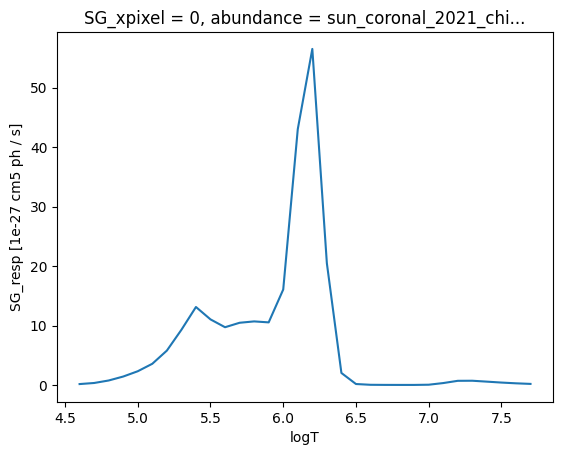

In [15]:
response_ci.SG_resp.squeeze().sel(vdop=0, method='nearest').plot()

In [16]:
p = ci_195_noise.flux/(ci_195_noise.flux.mean(dim='slit'))

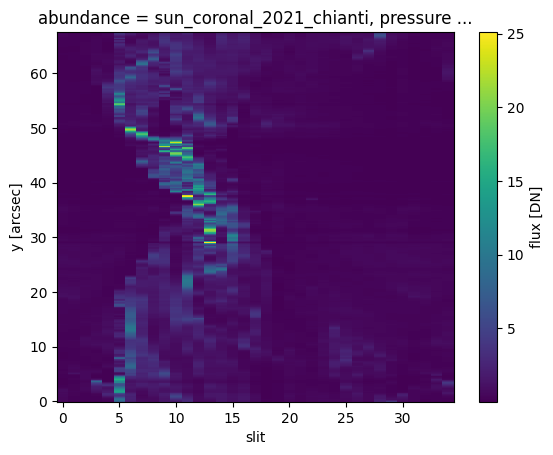

In [17]:
p.isel(step=0).plot()

In [18]:
c = (p-1)*response_ci.SG_resp/response_ci.SG_resp.max() + 1

In [160]:
y = 57
step = 0

In [161]:
respsum_dn_cor = respsum_dn.copy(deep=True)

In [162]:
respsum_dn_cor['SG_resp'] = respsum_dn_cor['SG_resp']/c.sel(y=y, step=step, method='nearest')

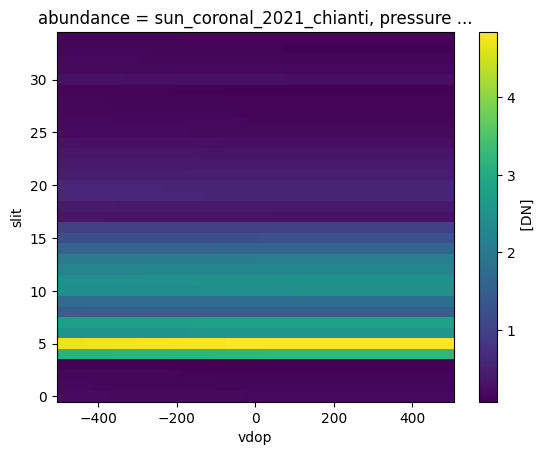

In [163]:
c.sel(y=y, step=step, logT=6.2, method='nearest').plot()

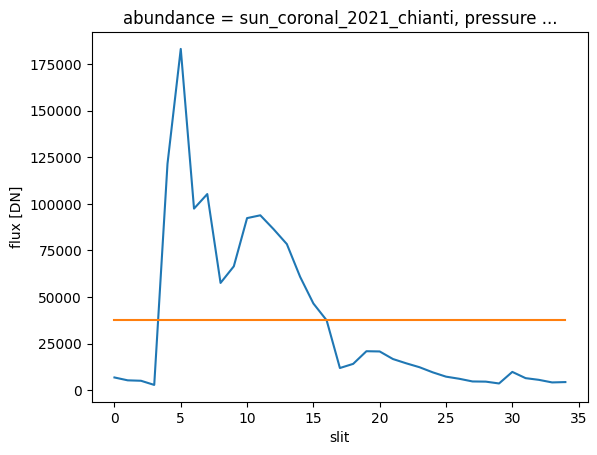

In [164]:
ci_195_noise.flux.sel(y=y, step=step, method='nearest').plot()
plt.plot([0, 34], [ci_195_noise.flux.sel(y=y, step=step, method='nearest').mean().values]*2)

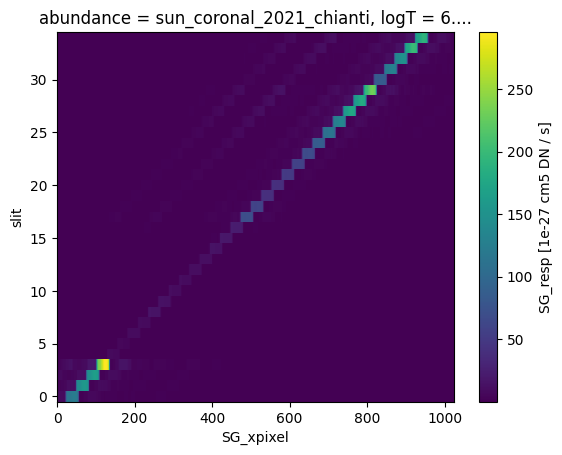

In [165]:
respsum_dn_cor.SG_resp.sel(channel=284, logT=6.2, method='nearest').sum('vdop').plot()
# plt.gca().set(xlim=[0, 1000])

In [167]:
specsum_noise_part = specsum_noise.sel(y=y, step=step, method='nearest')

In [168]:
from importlib import reload
reload(muse.inversions.inversions)
from muse.synthesis.synthesis import calc_error
from muse.inversions.inversions import mask_response, vdem_solve
noise0 = calc_error(specsum_noise_part).error
scaling = noise0.max()/noise0
vdem_inv_ci = vdem_solve(
    specsum_noise_part,
    respsum_dn_cor, 
    model=model,
    scaling = scaling, 
    serial = True,
)

2025-11-10 13:22:07.423 | INFO     | muse.inversions.inversions:vdem_solve:138 - updated shape of R: (3072, 113120)
2025-11-10 13:22:07.424 | INFO     | muse.inversions.inversions:vdem_solve:139 - updated shape of b: (3072, 1)
2025-11-10 13:22:27.439 | INFO     | muse.inversions.inversions:vdem_solve:158 - Running SDC in serial mode
2025-11-10 13:22:27.440 | INFO     | muse.inversions.inversions:vdem_solve:159 - mask: False, scaling: True, drop_pix: False


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:51<00:00, 51.99s/it]

2025-11-10 13:23:19.462 | INFO     | muse.inversions.inversions:vdem_solve:408 - Solve: units of spectrum: DN
2025-11-10 13:23:19.467 | INFO     | muse.inversions.inversions:vdem_solve:409 - Solve: units of response: 1e-27 cm5 DN / s
2025-11-10 13:23:19.470 | INFO     | muse.inversions.inversions:vdem_solve:418 - Solve: units of VDEM: 1e+27 s / cm5


In [169]:
from importlib import reload
reload(muse.inversions.inversions)
from muse.synthesis.synthesis import calc_error
from muse.inversions.inversions import mask_response, vdem_solve
noise0 = calc_error(specsum_noise_part).error
scaling = noise0.max()/noise0
vdem_inv = vdem_solve(
    specsum_noise_part,
    respsum_dn, 
    model=model,
    scaling = scaling, 
    serial = True,
)

2025-11-10 13:23:38.749 | INFO     | muse.inversions.inversions:vdem_solve:138 - updated shape of R: (3072, 113120)
2025-11-10 13:23:38.750 | INFO     | muse.inversions.inversions:vdem_solve:139 - updated shape of b: (3072, 1)
2025-11-10 13:23:58.271 | INFO     | muse.inversions.inversions:vdem_solve:158 - Running SDC in serial mode
2025-11-10 13:23:58.272 | INFO     | muse.inversions.inversions:vdem_solve:159 - mask: False, scaling: True, drop_pix: False


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:49<00:00, 49.59s/it]

2025-11-10 13:24:47.880 | INFO     | muse.inversions.inversions:vdem_solve:408 - Solve: units of spectrum: DN
2025-11-10 13:24:47.882 | INFO     | muse.inversions.inversions:vdem_solve:409 - Solve: units of response: 1e-27 cm5 DN / s
2025-11-10 13:24:47.885 | INFO     | muse.inversions.inversions:vdem_solve:418 - Solve: units of VDEM: 1e+27 s / cm5


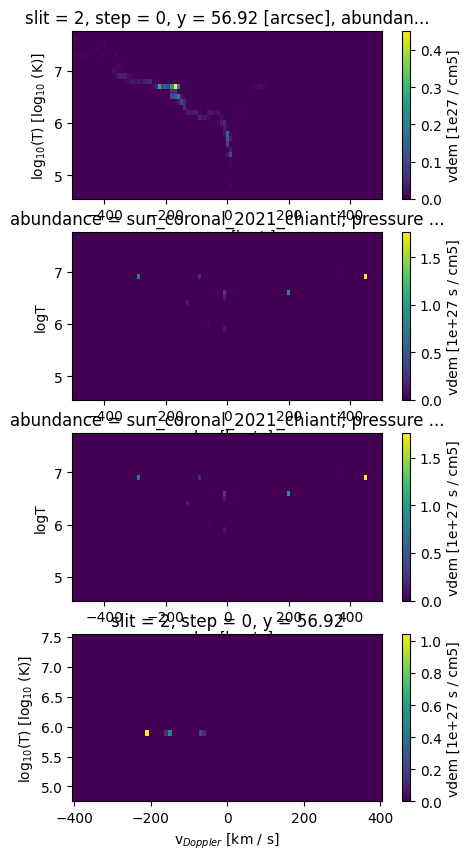

In [170]:
slit = 2
fig, ax = plt.subplots(4, 1, figsize=[5, 10])
vdem.vdem.sel(y=y, step=step, slit=slit, method='nearest').plot(ax=ax[0])
vdem_inv.vdem.sel(slit=slit, method='nearest').T.plot(ax=ax[1])
vdem_inv_ci.vdem.sel(slit=slit, method='nearest').T.plot(ax=ax[2])
vdem_inv_orig.vdem.sel(y=y, step=step, slit=slit, method='nearest').T.plot(ax=ax[3])

In [171]:
spec_inv_ci = exposure_time(vdem_synthesis(vdem_inv_ci, response_dn, sum_over=("logT", "vdop")), exp_time)

2025-11-10 13:24:50.557 | INFO     | muse.synthesis.synthesis:exposure_time:808 - Exposure time has been previously applied.


In [172]:
spec_inv = exposure_time(vdem_synthesis(vdem_inv, response_dn, sum_over=("logT", "vdop")), exp_time)

2025-11-10 13:24:52.190 | INFO     | muse.synthesis.synthesis:exposure_time:808 - Exposure time has been previously applied.


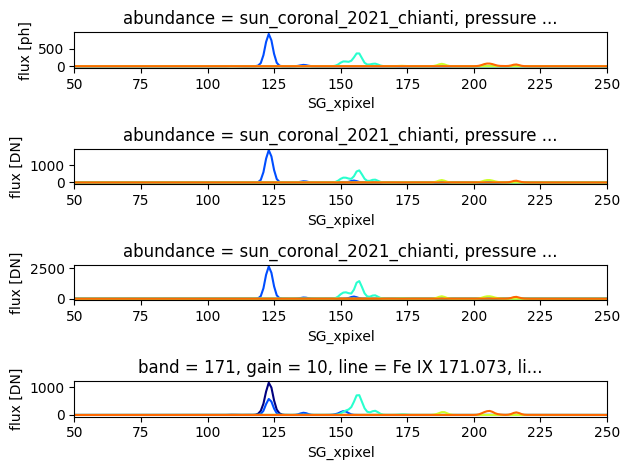

In [186]:
col = ['r', 'g', 'b']
slit0 = 3
nslit = 5
cmap = plt.get_cmap('jet')
col = [cmap(i/nslit) for i in range(nslit)]
line = 3
fig, ax = plt.subplots(4, 1)
for j in range(nslit):
    spec_gt.sel(y=y, step=step, method='nearest').flux.isel(
        line=line, slit=j+slit0).plot(color=col[j], ax=ax[0])
    spec_inv.flux.isel(line=line, slit=j+slit0).plot(color=col[j], ax=ax[1])
    spec_inv_ci.flux.isel(line=line, slit=j+slit0).plot(color=col[j], ax=ax[2])
    spec_inv_orig.sel(y=y, step=step, method='nearest').flux.isel(
        line=line, slit=j+slit0).plot(color=col[j], ax=ax[3])
for i in ax: i.set(xlim=[50, 250])    
plt.tight_layout()

In [174]:
spec_inv_orig = xr.open_zarr('/home/kyu/benchmark4/no_mask1/spec_inv_all.zarr').compute()
spec_inv_orig = spec_inv_orig.set_coords("SG_wvl")

In [175]:
spec_inv_orig = spec_inv_orig.isel(line=range(7))
spec_inv_orig['line'] = response.line
vdem_inv_orig = xr.open_zarr('/home/kyu/benchmark4/no_mask1/vdem_inv_all.zarr').compute()

In [176]:
line = response.line[[0, 3, 5]]
npix = 2
serial_gfat = False

In [177]:
mom_inv = gaussian_fitting_analysis(spec_inv, response, line_channel_key=line, 
                                    kwargs_obs={"npix": npix, "velocity_range": velocity_range_guided, "serial": serial_gfat})

In [178]:
mom_inv_ci = gaussian_fitting_analysis(spec_inv_ci, response, line_channel_key=line, 
                                    kwargs_obs={"npix": npix, "velocity_range": velocity_range_guided, "serial": serial_gfat})

In [179]:
mom_inv_orig = gaussian_fitting_analysis(
    spec_inv_orig.sel(y=y, step=step, method='nearest'), response, 
    line_channel_key=line, 
    kwargs_obs={"npix": npix, "velocity_range": velocity_range_guided, "serial": serial_gfat})

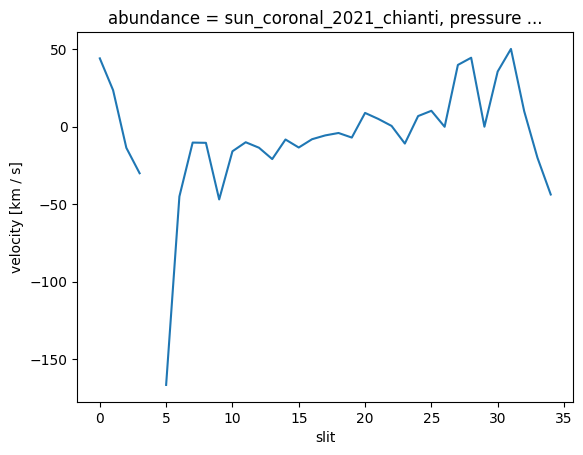

In [180]:
mom_inv.velocity.sel(line = line[1]).plot()

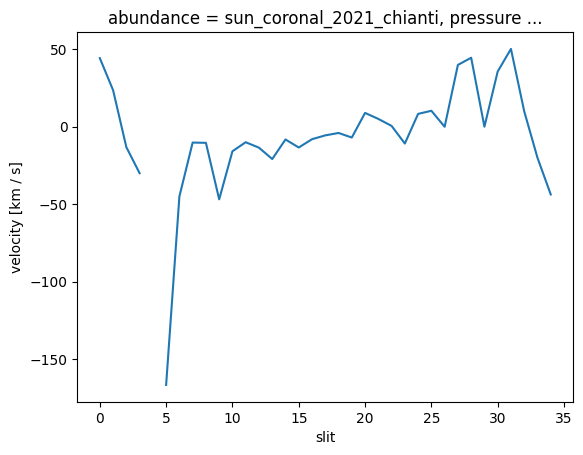

In [181]:
mom_inv_ci.velocity.sel(line = line[1]).plot()

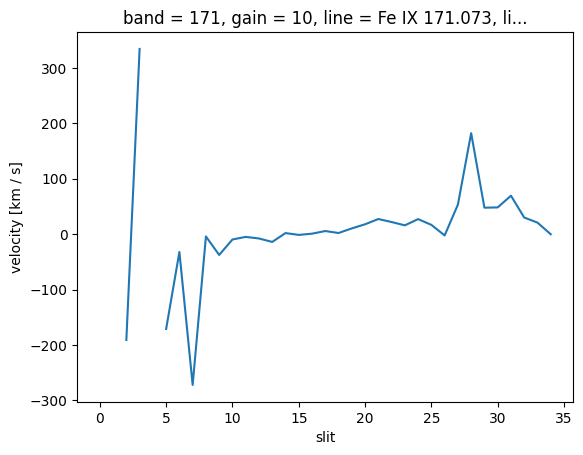

In [182]:
mom_inv_orig.velocity.sel(line = line[1]).plot()

In [265]:
from importlib import reload
reload(muse.inversions.inversions)
from muse.synthesis.synthesis import calc_error
from muse.inversions.inversions import mask_response, vdem_solve
noise0 = calc_error(spec_filled_sample).error
scaling = noise0.max()/noise0
vdem_inv = vdem_solve(
    spec_filled_sample,
    respsum, 
    model=model,
    scaling = scaling, 
    serial = True,
    mask = None,
)

2025-09-03 15:07:37.525 | INFO     | muse.inversions.inversions:vdem_solve:269 - updated shape of R: (3072, 98980)
2025-09-03 15:07:37.526 | INFO     | muse.inversions.inversions:vdem_solve:270 - updated shape of b: (3072, 1)


100%|████████████████████████████████████████████| 1/1 [02:05<00:00, 125.70s/it]

2025-09-03 15:09:44.994 | INFO     | muse.inversions.inversions:vdem_solve:847 - Solve: units of spectrum: DN / s
2025-09-03 15:09:44.996 | INFO     | muse.inversions.inversions:vdem_solve:848 - Solve: units of response: 1e-27 cm5 DN / s
2025-09-03 15:09:44.999 | INFO     | muse.inversions.inversions:vdem_solve:857 - Solve: units of VDEM: 1e+27 / cm5


In [27]:
em_max_ci_rs = ci_195_noise.flux/response_ci_dn.SG_resp/exp_time

In [29]:
fill_value = 0.25
flux_attrs = specsum_noise.flux.attrs
spec_filled = specsum_noise.copy(deep=True)
spec_filled['flux'] = xr.where(spec_filled.flux <= 0, fill_value, spec_filled.flux)/exp_time
spec_filled['flux'].attrs = {'units':'DN / s'}

In [70]:
spec_filled_sample = spec_filled.sel(y=y, step=step, method='nearest')
aa = (spec_filled_sample.flux/(respsum_dn.SG_resp+1e-30)).min(dim=['channel', 'SG_xpixel'])
em_max_ci_rs_sample = em_max_ci_rs.sel(y=y, step=step, logT=respsum_dn.logT, method='nearest').expand_dims(dim={'vdop':respsum_dn.vdop}).transpose(*aa.dims)

In [71]:
em_max = xr.where(aa > em_max_ci_rs_sample, em_max_ci_rs_sample, aa)

In [72]:
bb = em_max_ci_rs.sel(y=y, step=step, logT=respsum_dn.logT, method='nearest')

In [73]:
dem_max = xr.where(aa.sum('vdop') >= bb, 
                   bb, 
                   aa.sum('vdop')).expand_dims(dim={'vdop':respsum_dn.vdop}).transpose(*aa.dims)

In [74]:
em_max = xr.where(aa > dem_max, dem_max, aa)

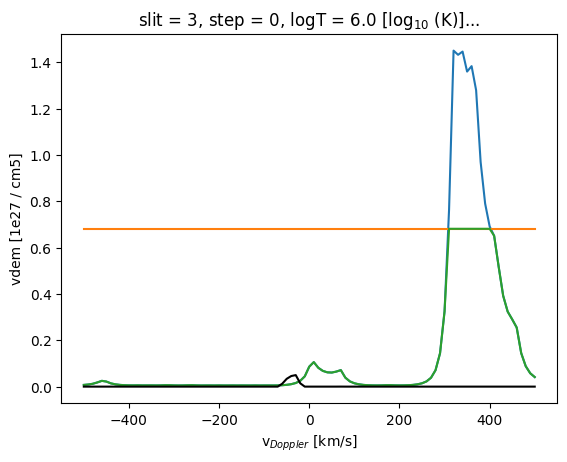

In [76]:
aa.sel(slit=3, logT=6.0, method='nearest').plot()
dem_max.sel(slit=3, logT=6.0, method='nearest').plot()
em_max.sel(slit=3, logT=6.0, method='nearest').plot()
vdem.vdem.sel(y=y, step=step, slit=3, logT=6.0, method='nearest').plot(c='k')

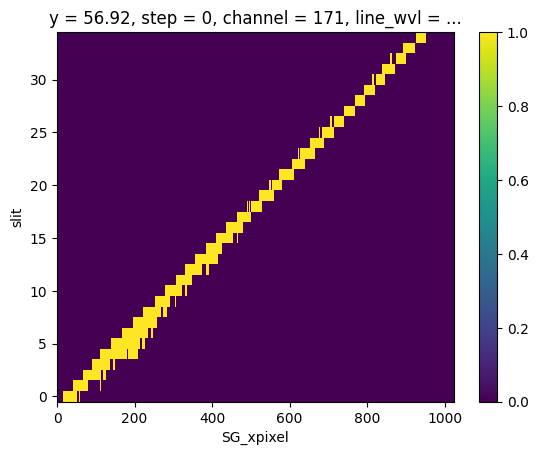

In [79]:
(spec_contribution.sel(channel=171).sum(dim=['vdop', 'logT']) > 2.24*10).plot()

In [63]:
spec_contribution = (em_max*respsum.SG_resp)*exp_time

NameError: name 'em_max' is not defined

In [262]:
ddm = xr.where((spec_contribution >= 2.24*2).any(dim=['channel', 'SG_xpixel']), 1, np.nan)

In [263]:
model = Lasso(alpha=1e-3, positive=True, fit_intercept=False, max_epochs=500)

In [266]:
spec_inv_mask = exposure_time(vdem_synthesis(vdem_inv_mask, response, sum_over=("logT", "vdop")), exp_time)

In [267]:
spec_inv = exposure_time(vdem_synthesis(vdem_inv, response, sum_over=("logT", "vdop")), exp_time)

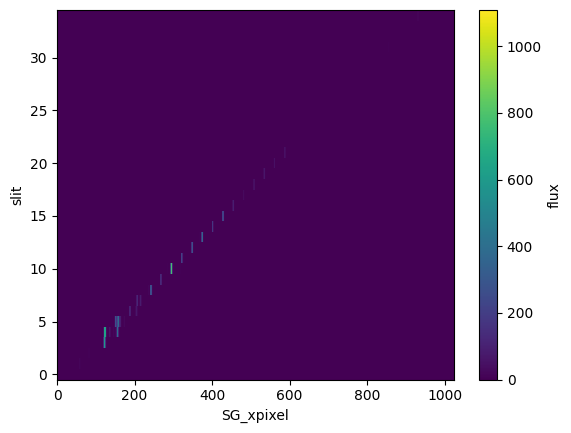

In [278]:
spec_inv_mask.flux.isel(line=[3,4]).sum('line').plot()

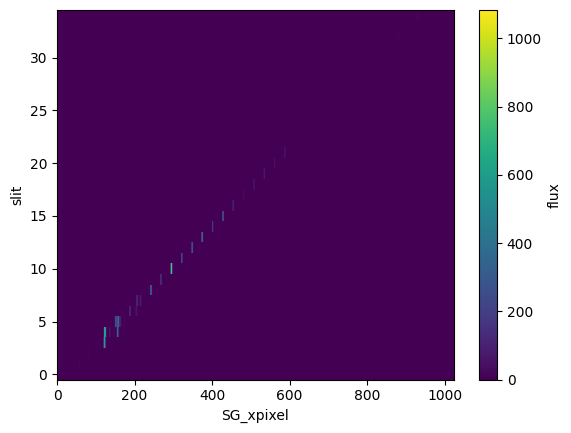

In [279]:
spec_inv.flux.isel(line=[3,4]).sum('line').plot()

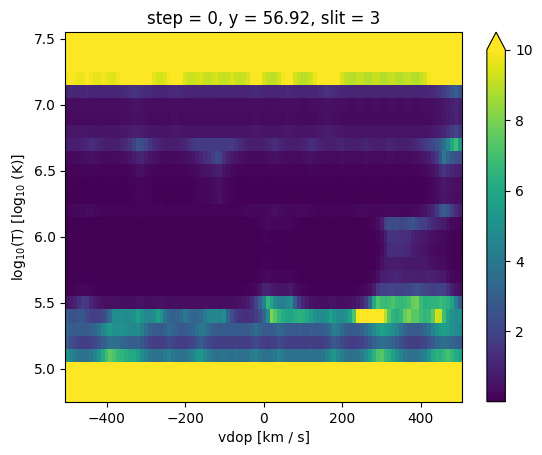

In [213]:
aa.sel(slit=3).T.plot(vmax=10)

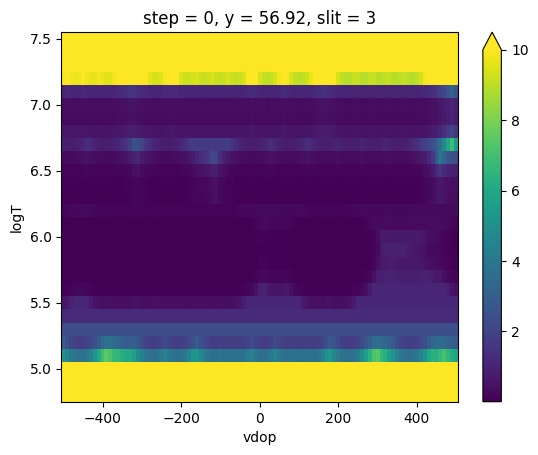

In [214]:
em_max.sel(slit=3).T.plot(vmax=10)

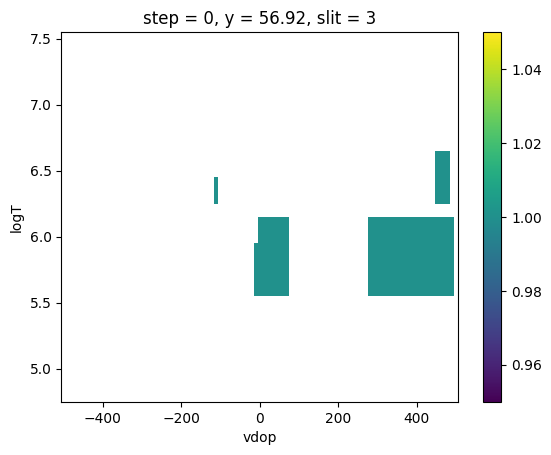

In [212]:
ddm.sel(slit=3).T.plot()

[(100.0, 200.0)]

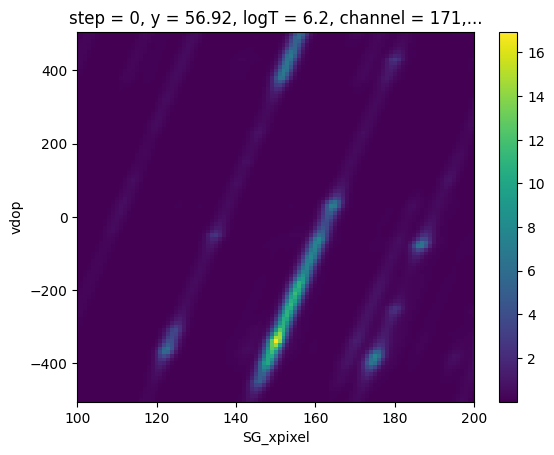

In [270]:
spec_contribution.sel(channel=171).sel(logT=6.2, method='nearest').sum('slit').plot()
plt.gca().set(xlim=[100, 200])

In [273]:
spec_gt = ph2dn(exposure_time(vdem_synthesis(vdem_rs.sel(logT=6.2, method='nearest'), 
                                       response, sum_over=('logT', 'slit')), exp_time), response)

[(100.0, 200.0)]

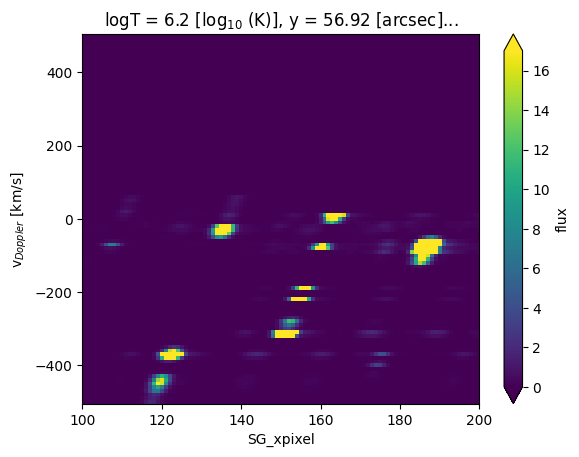

In [274]:
spec_gt.flux.isel(line=[3, 4]).sum('line').sel(y=y, step=step, method='nearest').plot(vmin=0, vmax=17)
plt.gca().set(xlim=[100, 200])

In [247]:
spec_gt

<xarray.Dataset> Size: 13GB
Dimensions:    (vdop: 101, y: 404, step: 11, line: 7, SG_xpixel: 1024)
Coordinates:
  * vdop       (vdop) int64 808B -500 -490 -480 -470 -460 ... 470 480 490 500
  * y          (y) float64 3kB 0.0 0.1674 0.3348 0.5022 ... 67.13 67.3 67.47
  * step       (step) int64 88B 0 1 2 3 4 5 6 7 8 9 10
    channel    (line) int64 56B 108 108 108 171 171 284 284
    gain       (line) int64 56B 10 10 10 10 10 10 10
    line_wvl   (line) float64 56B 108.4 108.1 108.4 171.1 171.1 284.2 285.0
  * line       (line) <U14 392B 'Fe XIX 108.355' 'Fe XXI' ... '[284] missing '
  * SG_xpixel  (SG_xpixel) int64 8kB 0 1 2 3 4 5 ... 1019 1020 1021 1022 1023
Data variables:
    flux       (vdop, y, step, line, SG_xpixel) float32 13GB 0.0 ... 0.0001276
Attributes:
    HISTORY:          ['create_resp_func_nullvel(line_list=line_list, instr_w...
    date created:     29-Oct-2024
    version:          0.2.dev52+g47d9862
    step_size:        0.4010416666666667
    step_size units:  arcsec
    date modified:    03-Sep-2025
    Chianti version:  10.1
    abundance:        sun_coronal_2021_chianti

In [228]:
spectrum_synthesis.flux.sel(y=y, step=step, method='nearest')

<xarray.DataArray 'flux' (slit: 35, line: 8, SG_xpixel: 1024)> Size: 1MB
array([[[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [5.2673321e-22, 2.7068977e-20, 1.1107570e-18, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [1.1021259e-03, 8.3907071e-04, 5.0203037e-04, ...,
         2.7931037e-07, 5.2902010e-07, 5.8140870e-07],
        ...,
        [2.4767358e-31, 8.5333713e-30, 2.5267532e-28, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [3.9518853e-03, 7.7880840e-03, 1.1071258e-02, ...,
         1.2185697e-05, 7.3386086e-06, 3.4678169e-06],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],

       [[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [2.5453331e-04, 3.1771103e-04, 4.5789487e-04, ...,
         1.5180635e-09, 3.0017904e-09, 5.9432224e-09],
...
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [1.1391509e-04, 7.6055599e-05, 4.2987460e-05, ...,
         2.5668408e-04, 1.5556801e-04, 1.0645529e-04],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],

       [[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [1.7368932e-09, 2.4044413e-09, 3.1851344e-09, ...,
         3.3193553e-04, 2.8363214e-04, 3.1401298e-04],
        ...,
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [3.2778516e-05, 5.0524315e-05, 7.4225492e-05, ...,
         1.1679430e-03, 1.6939320e-03, 2.0647345e-03],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00]]], dtype=float32)
Coordinates:
    SG_wvl     (line, slit, SG_xpixel) float64 2MB 107.7 107.7 ... 109.4 109.5
  * SG_xpixel  (SG_xpixel) int64 8kB 0 1 2 3 4 5 ... 1019 1020 1021 1022 1023
    channel    (line) int64 64B 108 108 108 171 171 284 284 195
    gain       (line) int64 64B 10 10 10 10 10 10 10 10
  * line       (line) <U14 448B 'Fe XIX 108.355' 'Fe XXI' ... '195'
    line_wvl   (line) float64 64B 108.4 108.1 108.4 171.1 ... 284.2 285.0 195.0
  * slit       (slit) int64 280B 0 1 2 3 4 5 6 7 8 ... 27 28 29 30 31 32 33 34
    step       int64 8B 0
    y          float64 8B 56.92
Attributes:
    exp_time:  0.6
    units:     ph

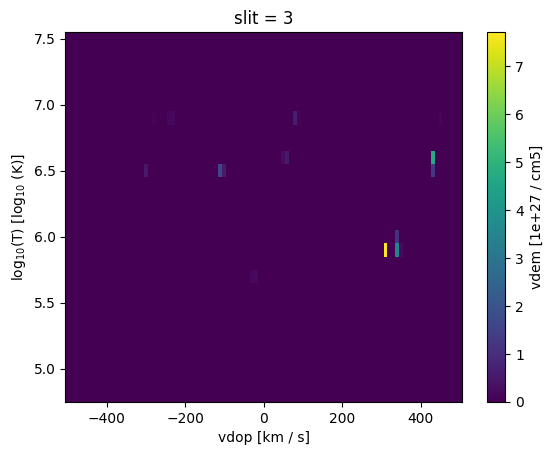

In [108]:
vdem_inv.vdem.sel(slit=3).T.plot()

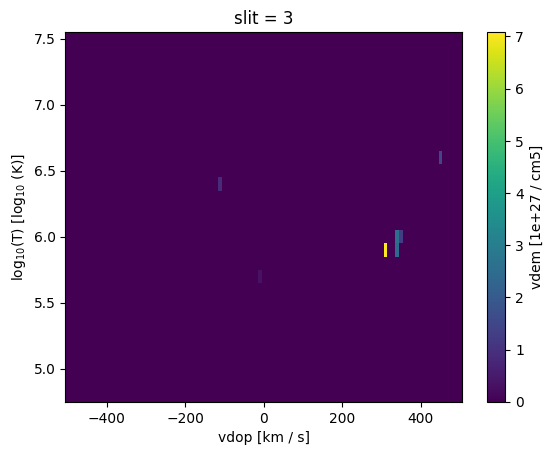

In [109]:
vdem_inv_mask.vdem.sel(slit=3).T.plot()

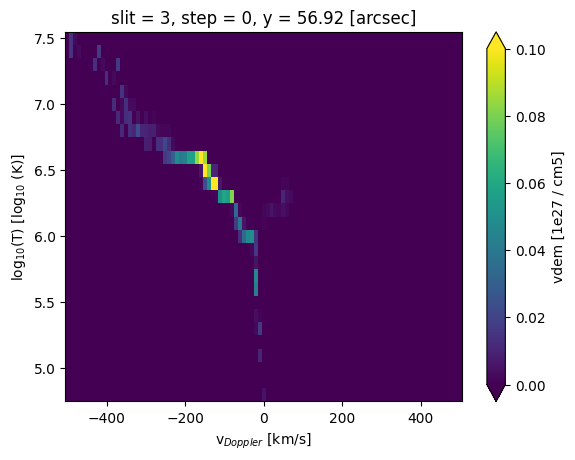

In [154]:
vdem_rs.vdem.sel(y=y, step=step, slit=3, method='nearest').plot(vmin=0, vmax=0.1)

[(0.0, 100.0)]

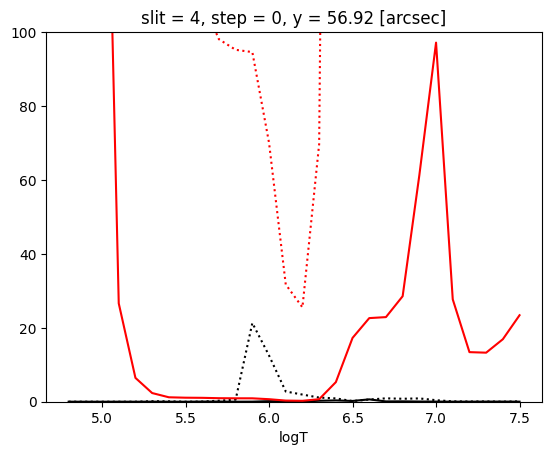

In [169]:
vdem_rs.vdem.sel(y=y, step=step, slit=3, method='nearest').sum('vdop').plot(c='k')
vdem_rs.vdem.sel(y=y, step=step, slit=4, method='nearest').sum('vdop').plot(c='k', ls=':')
em_max_ci_rs.sel(y=y, slit=3, step=step, method='nearest').plot(c='r')
em_max_ci_rs.sel(y=y, slit=4, step=step, method='nearest').plot(c='r', ls=':')
plt.gca().set(ylim=[0, 1e2])

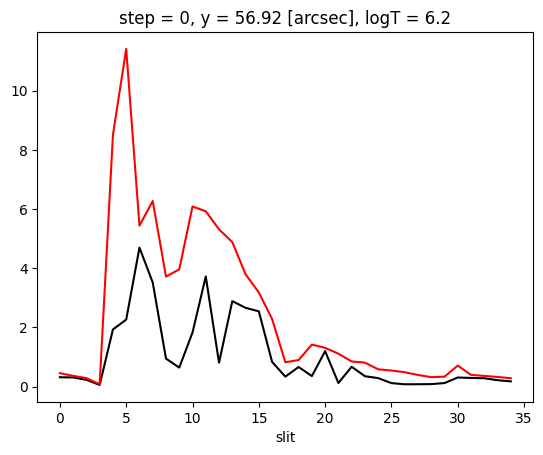

In [174]:
vdem_rs.vdem.sel(y=y, step=step, logT=6.2, method='nearest').sum('vdop').plot(c='k')
(em_max_ci_rs.sel(y=y, step=step, logT=6.2, method='nearest')/3).plot(c='r')


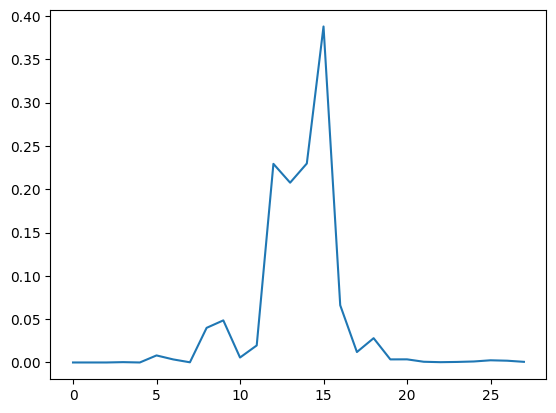

In [163]:
a01 = vdem_rs.vdem.sel(y=y, step=step, slit=3, method='nearest').sum('vdop')
a02 = em_max_ci_rs.sel(y=y, slit=3, step=step, method='nearest')
plt.plot(a01/a02)

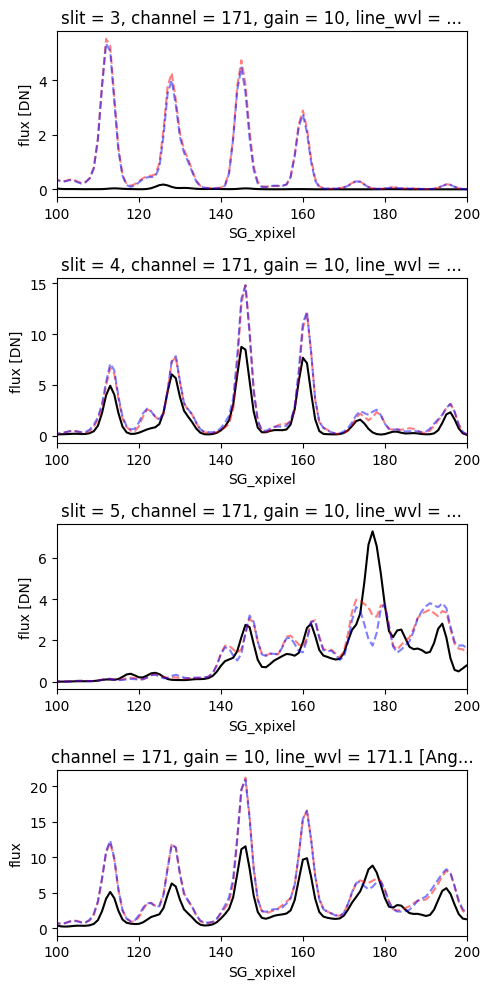

In [268]:
line = 4
fig, ax = plt.subplots(4, 1, figsize=[5, 10])
for i, slit in enumerate(range(3, 6)):
    # c = ['r', 'g', 'b'][i]
    spectrum_synthesis.flux.sel(y=y, step=step, method='nearest').isel(
        line=line, slit=slit).plot(color='k', ls='-', alpha=1, ax=ax[i])
    spec_inv.flux.isel(line=line, slit=slit).plot(color='r', ls='--', alpha=0.5, ax=ax[i])
    spec_inv_mask.flux.isel(line=line, slit=slit).plot(color='b', ls='--', alpha=0.5, ax=ax[i])
spectrum_synthesis.flux.sel(y=y, step=step, method='nearest').isel(line=line).sum('slit').plot(
    color='k', ls='-', alpha=1, ax=ax[3])
spec_inv.flux.isel(line=line).sum('slit').plot(color='r', ls='--', alpha=0.5, ax=ax[3])
spec_inv_mask.flux.isel(line=line).sum('slit').plot(color='b', ls='--', alpha=0.5, ax=ax[3])

for i in range(4):
    ax[i].set(xlim=[100, 200])    
plt.tight_layout()

In [121]:
print(spectrum_synthesis.flux.isel(line=3).sum().values, 
      spec_inv.flux.isel(line=3).sum().values, 
      spec_inv_mask.flux.isel(line=3).sum().values)

82371610.0 24216.52 23922.111


In [122]:
spectrum_synthesis.flux.attrs

{'exp_time': 0.6, 'units': 'ph'}

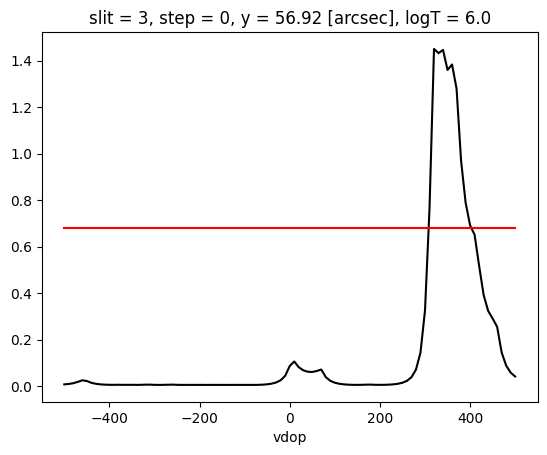

In [269]:
aa.sel(slit=3, logT=6.0, method='nearest').plot(c='k')
em_max_ci_rs_sample.sel(slit=3, logT=6.0, method='nearest').plot(c='r')

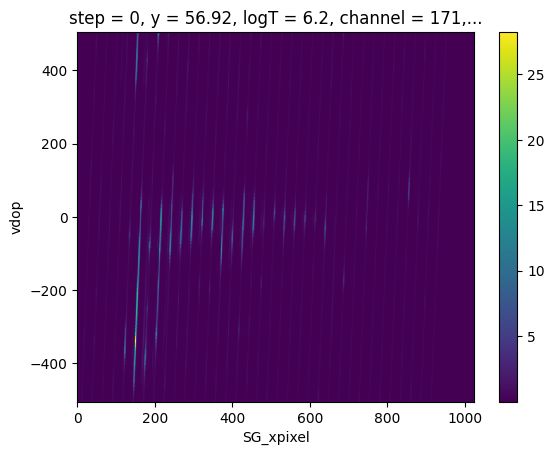

In [33]:
spec_contribution.isel(channel=1).sel(logT=6.2, method='nearest').sum('slit').plot()

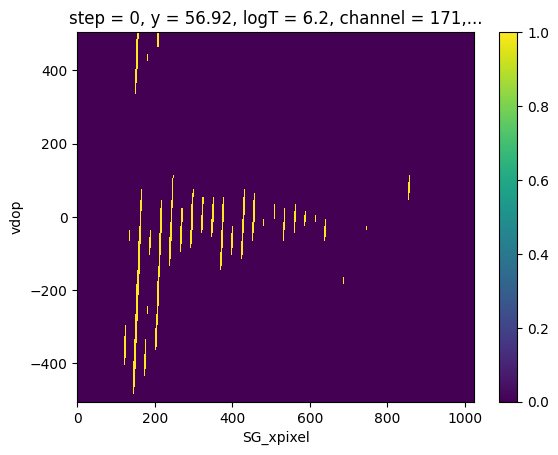

In [34]:
(spec_contribution.isel(channel=1).sel(logT=6.2, method='nearest').sum('slit')> 2.24).plot()

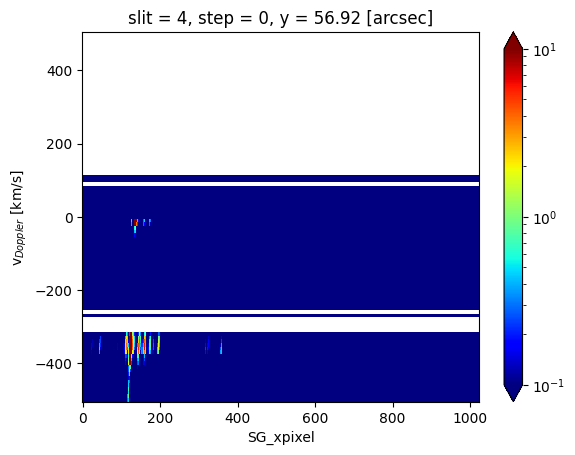

In [144]:
syn.sel(slit=4, method='nearest').sum('logT').plot(norm=colors.LogNorm(0.1, 10), cmap='jet')

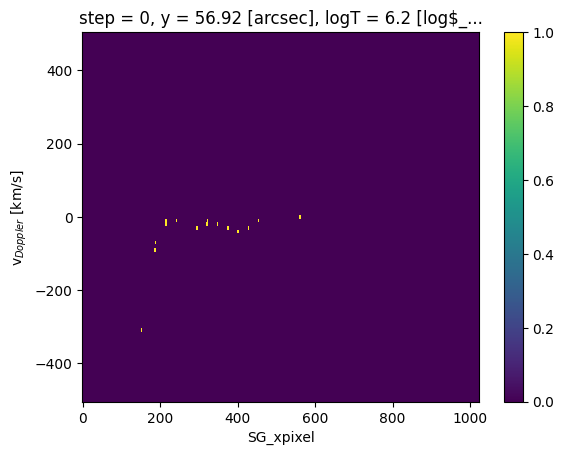

In [43]:
(syn.sel(logT=6.2, method='nearest').sum('slit')>2.24).plot(vmin=0)

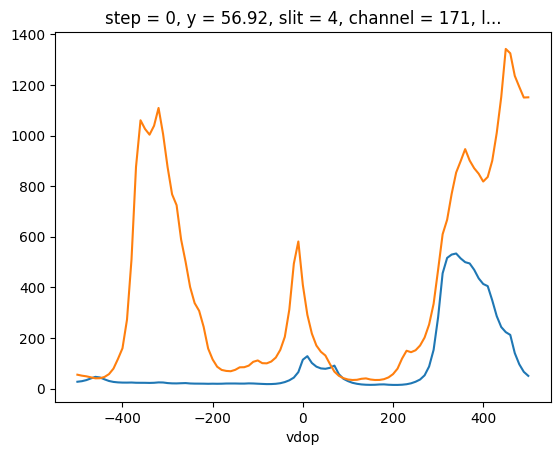

In [152]:
spec_contribution.isel(channel=1).sel(slit=3).sum(dim=['logT', 'SG_xpixel']).plot()
spec_contribution.isel(channel=1).sel(slit=4).sum(dim=['logT', 'SG_xpixel']).plot()

[None]

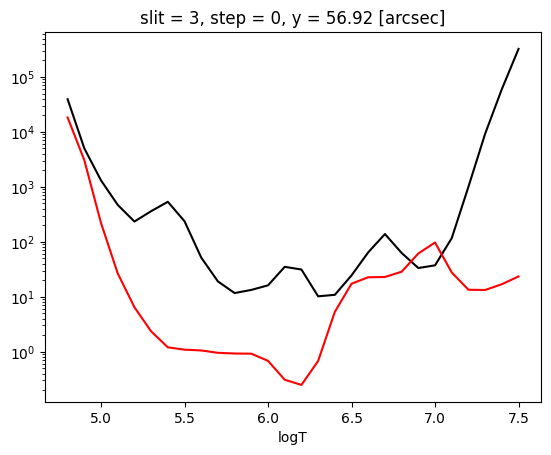

In [25]:
aa.sel(slit=3).sum('vdop').plot(c='k')
em_max_ci_rs.sel(y=y, step=step, slit=3, method='nearest').plot(c='r')
plt.gca().set(yscale='log')

[None]

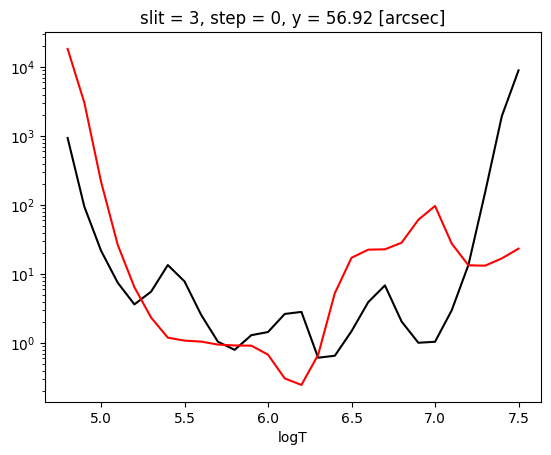

In [26]:
aa.sel(slit=3).max('vdop').plot(c='k')
em_max_ci_rs.sel(y=y, step=step, slit=3, method='nearest').plot(c='r')
plt.gca().set(yscale='log')

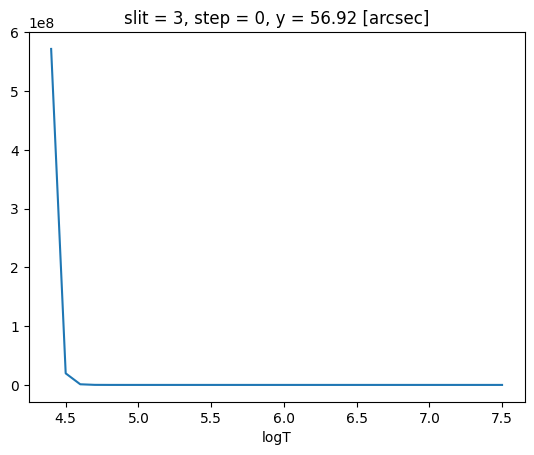

In [76]:
em_max_ci_rs.sel(y=y, step=step, slit=3, method='nearest').plot()

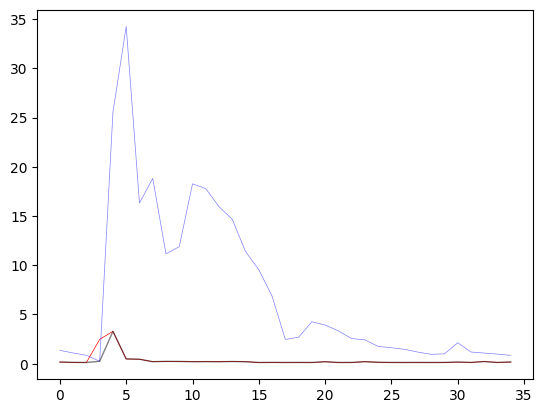

In [39]:
logT = 6.2
vdop = 450
plt.plot(aa.sel(logT=logT, vdop=vdop, method='nearest').values.flatten(), lw=0.5, c='r')
plt.plot(em_max_ci_rs_sample.sel(logT=logT, vdop=vdop, method='nearest').values.flatten(), lw=0.5, alpha=0.5, c='b')
plt.plot(em_max.sel(logT=logT, vdop=vdop, method='nearest').values.flatten(), lw=1, alpha=0.5, c='k')
# plt.gca().set(xlim=[1e4, 1e4+1e3], yscale='log')


[None]

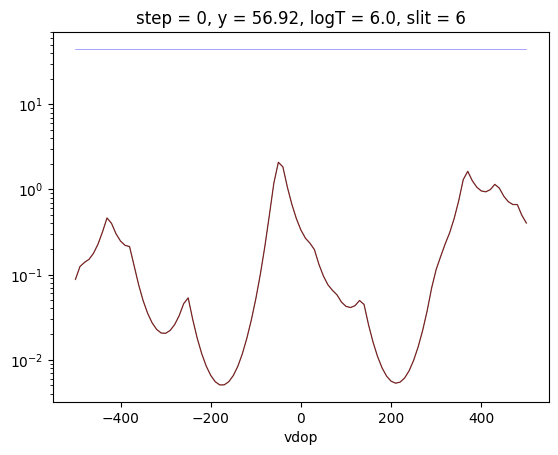

In [51]:
logT = 6
slit = 6
aa.sel(logT=logT, slit=slit, method='nearest').plot(lw=0.5, c='r')
em_max_ci_rs_sample.sel(logT=logT, slit=slit, method='nearest').plot(lw=0.5, alpha=0.5, c='b')
em_max.sel(logT=logT, slit=slit, method='nearest').plot(lw=1, alpha=0.5, c='k')
plt.gca().set(yscale='log')


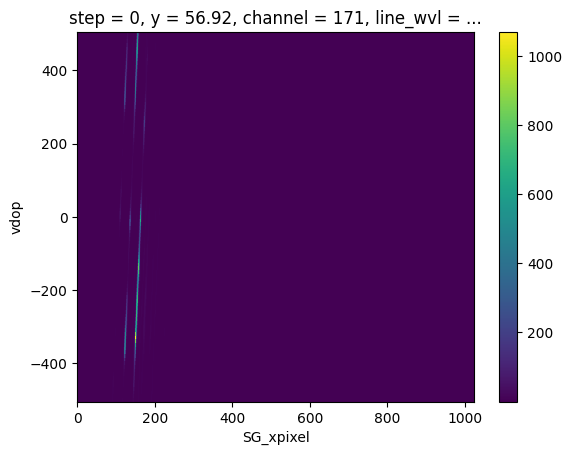

In [54]:
spec_contribution.sel(slit=range(3, 6), method='nearest').sum(dim=['slit', 'logT']).isel(channel=1).plot()

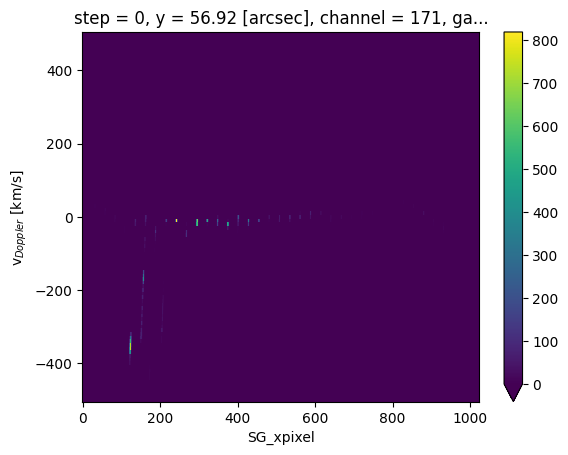

In [68]:
(vdem_rs.vdem.sel(y=y, step=step, method='nearest')*response.SG_resp.isel(line=3)).sum(dim=['slit', 'logT']).plot(vmin=0)

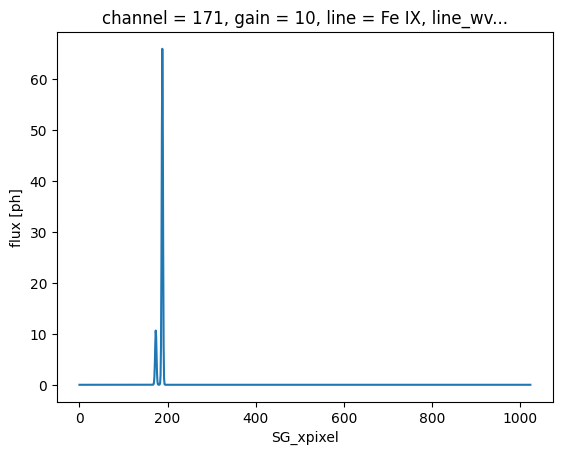

In [56]:
spectrum_synthesis.flux.sel(slit=slit, y=y, step=step, method='nearest').isel(line=3).plot()

[(100.0, 200.0)]

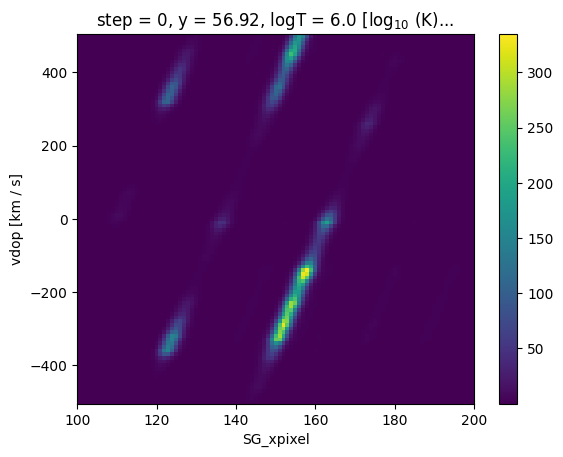

In [401]:
spec_cont = aa*respsum.SG_resp
spec_cont.sel(slit=range(3, 6), logT=6, method='nearest').sum('slit').isel(channel=1).plot()
plt.gca().set(xlim=[100, 200])

[(100.0, 200.0)]

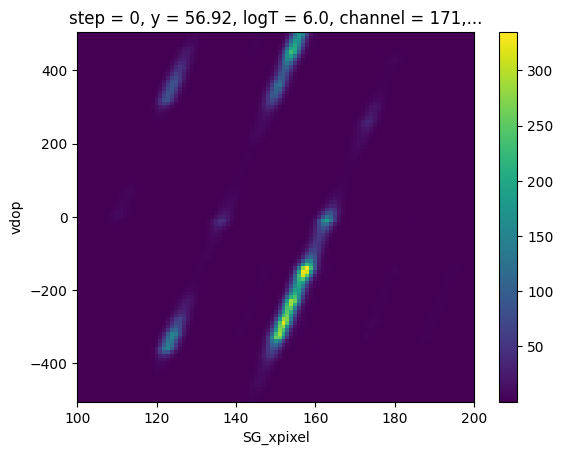

In [400]:
spec_contribution.sel(slit=range(3, 6), logT=6, method='nearest').sum('slit').isel(channel=1).plot()
plt.gca().set(xlim=[100, 200])

[(100.0, 200.0)]

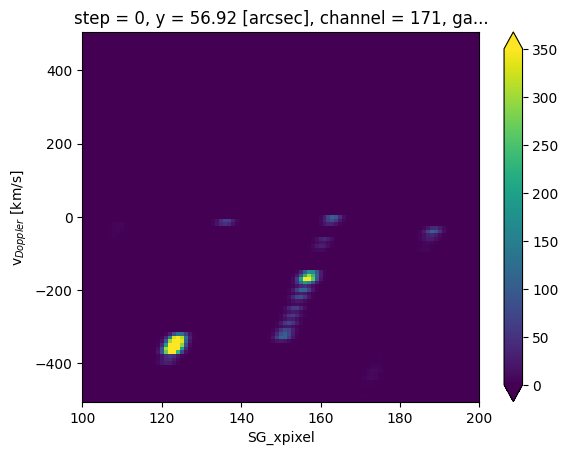

In [438]:
(vdem_rs.vdem.sel(y=y, step=step, method='nearest')*response.SG_resp.isel(line=3)).sum(dim=['slit', 'logT']).plot(vmin=0, vmax=350)
plt.gca().set(xlim=[100, 200])

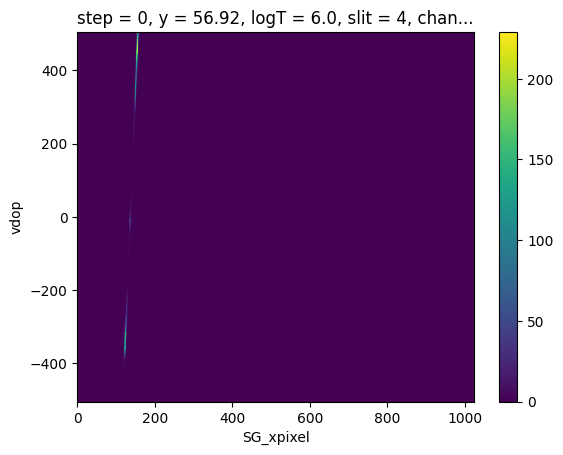

In [398]:
spec.sel(slit=4, logT=6, method='nearest').isel(channel=1).plot()

In [7]:
import gc
import time
from copy import deepcopy
from multiprocessing import cpu_count

import astropy.units as u
import GPUtil
import numpy as np
import torch
import xarray as xr
from scipy.sparse import csr_matrix
from threadpoolctl import threadpool_limits
from tqdm import tqdm

from muse import logger
from muse.instr.gausslobes import gausslobes
from muse.utils.utils import add_history

@torch.compile(mode="reduce-overhead")
@torch.no_grad
def mass_screen_gcompile(RG, ysG0, fill_value=None, threshold=0, return_max=False):
    """
    RG:   [SG_xpixel * bands, vdem size]
    ysG0: [SG_xpixel * bands, part of y * step]
    TBD fill help
    """
    if fill_value is not None:
        ysG0 = torch.where(ysG0 <= 0, fill_value, ysG0)
    maxBnd = torch.amin(ysG0[:, :, None] / RG[:, None, :], dim=0, keepdims=True)
    keep0 = torch.any(RG[:, None, :] * maxBnd >= threshold, dim=0)
    if return_max:
        return torch.where(keep0, 1, float("nan")), maxBnd
    return torch.where(keep0, 1, float("nan"))


def mass_screen_wcompile(R, ys, data_driven_mask_model, data_driven_mask_keyword, 
                         cuda_device=0, return_max=False):
    """
    thres: [SG_xpixel * bands, 1, 1]
    TBD fill help
    """
    CUDA = CPU = False
    if torch.cuda.is_available():
        logger.info("Using Cuda")
        CUDA = True
        RG = torch.from_numpy(R).cuda(device=cuda_device)
    else:
        logger.info("Using CPU")
        CPU = True
        RG = torch.from_numpy(R)
    R_size = R.nbytes / (2**20)
    ys_size = ys.nbytes / (2**20)
    gpu = GPUtil.getGPUs()[cuda_device]
    free_memory = gpu.memoryFree
    batchSize = int(free_memory // (R_size + ys_size)) * 10
    keepNP = np.zeros((ys.shape[1], R.shape[1]), dtype=float)
    maxBndNP = np.zeros((ys.shape[1], R.shape[1]), dtype=float)
    numBatches = ys.shape[1] // batchSize
    numBatches += 1 if ys.shape[1] % batchSize != 0 else 0
    if CUDA:
        ysG = torch.from_numpy(ys).cuda(device=cuda_device)
    if CPU:
        ysG = torch.from_numpy(ys)
    for batchI in tqdm(range(numBatches)):
        batchLow = batchSize * batchI
        batchHigh = min(batchSize * (batchI + 1), ys.shape[1])
        keep = torch.zeros((batchSize, R.shape[1]), dtype=float)
        ysG0 = ysG[:, batchLow:batchHigh]  # [3072, part of 4444]
        if return_max:
            keep, maxBnd = data_driven_mask_model(RG, ysG0, **data_driven_mask_keyword, 
                                                 return_max=return_max)
            maxBndNP[batchLow:batchHigh, :] = maxBnd.cpu().numpy()
        else:
            keep = data_driven_mask_model(RG, ysG0, **data_driven_mask_keyword)
        keepNP[batchLow:batchHigh, :] = keep.cpu().numpy()
    del ysG, RG
    gc.collect()
    torch.cuda.empty_cache()
    if return_max:
        return keepNP, maxBndNP
    return keepNP


def mask_response(
    spectrum,
    response,
    data_driven_mask_model=mass_screen_gcompile,
    data_driven_mask_keyword=None,
    cuda_device=0,
    return_max=False,
):
    """
    TBD fill help.
    """
    if data_driven_mask_keyword is None:
        data_driven_mask_keyword = {"fill_value": 0.5, "threshold": 2.24}
    assert "slit" not in spectrum.flux.dims, "Use sum_lines_slits_per_band function for spectrum"
    assert "line" not in spectrum.flux.dims, "Use sum_lines_slits_per_band function for spectrum"
    assert "line" not in response.SG_resp.dims, "Use sum_lines_per_band function for response function"

    spectrum = spectrum.copy(deep=True)
    spec_axis_order = tuple(set(response.dims) & set(spectrum.dims))
    spec_axis_order_diff = tuple(set(spectrum.dims) - set(response.dims))
    spec_axis_order_all = np.append(spec_axis_order, spec_axis_order_diff)
    resp_axis_order_diff = tuple(set(response.dims) - set(spectrum.dims))
    resp_axis_order_all = np.append(spec_axis_order, resp_axis_order_diff)
    logger.debug(f"match: {spec_axis_order}")
    logger.debug(f"extra spec: {spec_axis_order_diff}")
    logger.debug(f"extra resp: {resp_axis_order_diff}")
    logger.debug(f"spectrum dims: {spectrum.dims}")
    logger.debug(f"spec_axis_order_all: {spec_axis_order_all}")
    logger.debug(f"response dims: {response.dims}")
    logger.debug(f"resp_axis_order_all: {resp_axis_order_all}")
    logger.debug(f"shape of response.SG_resp: {np.shape(response.SG_resp)}")
    b = spectrum.flux.transpose(*spec_axis_order_all).data
    R = response.SG_resp.transpose(*resp_axis_order_all).compute()
    logger.debug(f"shape of R: {np.shape(R)}")
    logger.debug(f"shape of b: {np.shape(b)}")
    resp_diff_size = 1
    resp_diff_size_arr = []
    for k in resp_axis_order_diff:
        resp_diff_size *= response.coords[k].size
        resp_diff_size_arr.append(response.coords[k].size)
    spec_diff_size = 1
    spec_diff_size_arr = []
    for k in spec_axis_order_diff:
        spec_diff_size *= spectrum.coords[k].size
        spec_diff_size_arr.append(spectrum.coords[k].size)
    spec_size = 1
    spec_size_arr = []
    for k in spec_axis_order:
        spec_size *= spectrum.coords[k].size
        spec_size_arr.append(spectrum.coords[k].size)
    R = R.data.reshape(spec_size, resp_diff_size).astype("float32")
    b = b.reshape(spec_size, spec_diff_size).astype("float32")
    logger.debug(f"updated shape of R: {np.shape(R)}")
    logger.debug(f"updated shape of b: {np.shape(b)}")
    logger.debug(f"resp_diff_size_arr: {resp_diff_size_arr}")
    logger.info(f"threshold: {data_driven_mask_keyword['threshold']} {spectrum.flux.attrs['units']}")
    logger.info(f"fill_value: {data_driven_mask_keyword['fill_value']} {spectrum.flux.attrs['units']}")
    if cuda_device:
        with torch.cuda.device(f"cuda:{cuda_device}"):
            logger.debug(f"Using cuda device: {torch.cuda.current_device()}")
            keep = mass_screen_wcompile(R, b, data_driven_mask_model, data_driven_mask_keyword, 
                                        cuda_device, return_max=return_max)
    else:
        keep = mass_screen_wcompile(R, b, data_driven_mask_model, data_driven_mask_keyword, 
                                    cuda_device, return_max=return_max)
    resp_axis_order_diff_size = [response.dims[dims_name] for dims_name in resp_axis_order_diff]
    spec_axis_order_diff_size = [spectrum.dims[dims_name] for dims_name in spec_axis_order_diff]
    if return_max:
        maxBnd = keep[1]
        keep = keep[0]
        maxBnd = xr.DataArray(
            keep.reshape(np.append(resp_axis_order_diff_size, spec_axis_order_diff_size)),
            dims=np.append(resp_axis_order_diff, spec_axis_order_diff))
        for k in resp_axis_order_diff:
            maxBnd[k] = response.coords[k]
        for k in spec_axis_order_diff:
            maxBnd[k] = spectrum.coords[k]
    mask = xr.DataArray(
        keep.reshape(np.append(resp_axis_order_diff_size, spec_axis_order_diff_size)),
        dims=np.append(resp_axis_order_diff, spec_axis_order_diff),
    )
    for k in resp_axis_order_diff:
        mask[k] = response.coords[k]
    for k in spec_axis_order_diff:
        mask[k] = spectrum.coords[k]
    logger.info(f"volume to be used: {(np.sum(~np.isnan(keep)) / keep.size) * 1e2:3.1f} %")

    if return_max: return mask, maxBnd
    return mask

In [355]:
from importlib import reload
reload(muse.inversions.inversions)
from muse.synthesis.synthesis import calc_error
from muse.inversions.inversions import mask_response, vdem_solve
noise0 = calc_error(spec_filled_sample).error
scaling = noise0.max()/noise0
vdem_inv_mask = vdem_solve(
    spec_filled_sample,
    respsum, 
    model=model,
    scaling = scaling, 
    serial = True,
    mask = ddm,
)

2025-08-20 11:20:36.468 | INFO     | muse.inversions.inversions:vdem_solve:269 - updated shape of R: (3072, 98980)
2025-08-20 11:20:36.470 | INFO     | muse.inversions.inversions:vdem_solve:270 - updated shape of b: (3072, 1)


100%|█████████████████████████████████████████████| 1/1 [00:56<00:00, 56.07s/it]

2025-08-20 11:21:50.049 | INFO     | muse.inversions.inversions:vdem_solve:847 - Solve: units of spectrum: DN / s
2025-08-20 11:21:50.050 | INFO     | muse.inversions.inversions:vdem_solve:848 - Solve: units of response: 1e-27 cm5 DN / s
2025-08-20 11:21:50.109 | INFO     | muse.inversions.inversions:vdem_solve:857 - Solve: units of VDEM: 1e+27 / cm5


In [356]:
from importlib import reload
reload(muse.inversions.inversions)
from muse.synthesis.synthesis import calc_error
from muse.inversions.inversions import mask_response, vdem_solve
noise0 = calc_error(spec_filled_sample).error
scaling = noise0.max()/noise0
vdem_inv = vdem_solve(
    spec_filled_sample,
    respsum, 
    model=model,
    scaling = scaling, 
    serial = True,
    mask = None,
)

2025-08-20 11:21:52.836 | INFO     | muse.inversions.inversions:vdem_solve:269 - updated shape of R: (3072, 98980)
2025-08-20 11:21:52.837 | INFO     | muse.inversions.inversions:vdem_solve:270 - updated shape of b: (3072, 1)


100%|████████████████████████████████████████████| 1/1 [01:55<00:00, 115.98s/it]

2025-08-20 11:24:01.190 | INFO     | muse.inversions.inversions:vdem_solve:847 - Solve: units of spectrum: DN / s
2025-08-20 11:24:01.195 | INFO     | muse.inversions.inversions:vdem_solve:848 - Solve: units of response: 1e-27 cm5 DN / s
2025-08-20 11:24:01.199 | INFO     | muse.inversions.inversions:vdem_solve:857 - Solve: units of VDEM: 1e+27 / cm5


In [381]:
spec_inv_mask = vdem_synthesis(vdem_inv_mask, response, sum_over=("logT", "vdop"))

In [382]:
spec_inv = vdem_synthesis(vdem_inv, response, sum_over=("logT", "vdop"))

In [383]:
spec_gt = vdem_synthesis(vdem_rs.sel(y=y, step=step, logT=response.logT, method='nearest'), response, 
                         sum_over=("logT", "vdop"))

NameError: name 'spec_inv' is not defined

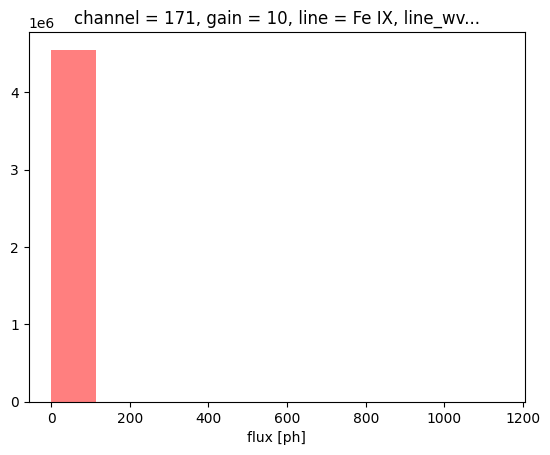

In [46]:
for i, slit in enumerate(range(3, 6)):
    c = ['r', 'g', 'b'][i]
    spectrum_synthesis.flux.isel(line=3, slit=slit).plot(color=c, ls='-', alpha=0.5)
    spec_inv.flux.isel(line=3, slit=slit).plot(color=c, ls='--', alpha=0.5)
    spec_inv_mask.flux.isel(line=3, slit=slit).plot(color=c, ls=':', alpha=0.5)
plt.gca().set(xlim=[100, 200])    

[(100.0, 200.0)]

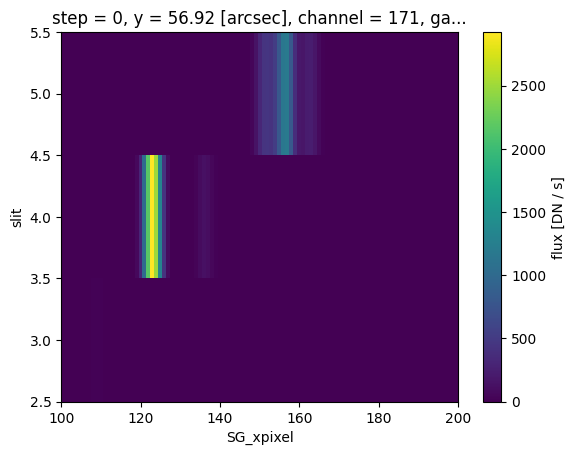

In [389]:
spec_gt.flux.isel(line=3, slit=range(3, 6)).plot()
plt.gca().set(xlim=[100, 200])

[(100.0, 200.0)]

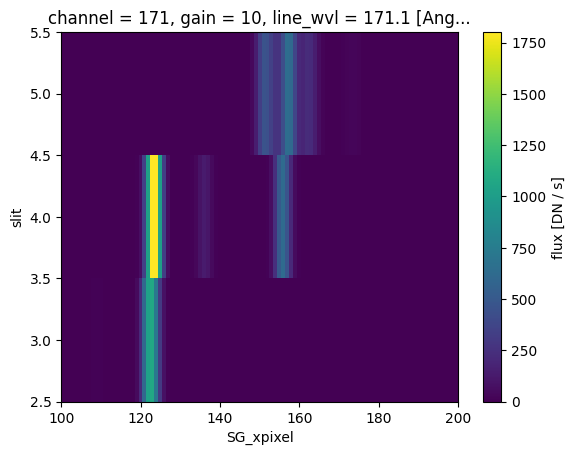

In [390]:
spec_inv.flux.isel(line=3, slit=range(3, 6)).plot()
plt.gca().set(xlim=[100, 200])

[(100.0, 200.0)]

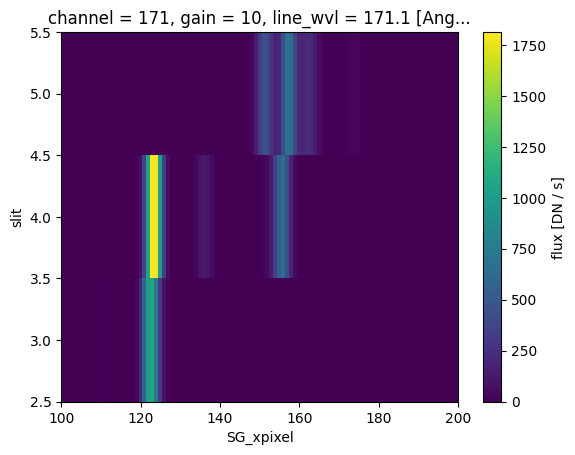

In [391]:
spec_inv_mask.flux.isel(line=3, slit=range(3, 6)).plot()
plt.gca().set(xlim=[100, 200])

In [359]:
vdem_rs.vdem.sel(y=y, step=step, method='nearest')

<xarray.DataArray 'vdem' (logT: 32, vdop: 101, slit: 35)> Size: 905kB
array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
...
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 3.31959307e-06],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[1.81927451e-02, 1.17280294e-04, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [4.74371490e-02, 0.00000000e+00, 0.00000000e+00, ...,
         2.92562779e-03, 0.00000000e+00, 0.00000000e+00],
        [1.49676619e-02, 5.07775233e-03, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]])
Coordinates:
  * slit     (slit) int64 280B 0 1 2 3 4 5 6 7 8 ... 26 27 28 29 30 31 32 33 34
    step     int64 8B 0
    y        float64 8B 56.92
  * vdop     (vdop) int64 808B -500 -490 -480 -470 -460 ... 460 470 480 490 500
  * logT     (logT) float64 256B 4.4 4.5 4.6 4.7 4.8 4.9 ... 7.1 7.2 7.3 7.4 7.5
Attributes:
    description:  DEM(T,vel,x,y)
    time:         555806
    units:        1e27 / cm5

In [ ]:
vdem.vdem.sel(y=y

In [316]:
thres = 2.24/exp_time*1e-1
mask = xr.where(em_max > thres, 1, np.nan)
print(thres, mask.sum().values)

0.3733333333333334 59025.0


In [290]:
from skglm import Lasso, ElasticNet, WeightedLasso
model = Lasso(alpha=1e-3, positive=True, fit_intercept=False, max_epochs=500) 

<module 'muse.inversions.inversions' from '/home/kyu/muse_hub/muse/muse/inversions/inversions.py'>

In [ ]:
from muse.synthesis.synthesis import calc_error
from muse.inversions.inversions import mask_response, vdem_solve
noise0 = calc_error(spec_filled_sample).error
scaling = noise0.max()/noise0
vdem_inv = vdem_solve(
    spec_filled_sample,
    respsum, 
    model=model,
    scaling = scaling, 
    serial = True,
    mask = mask,
)

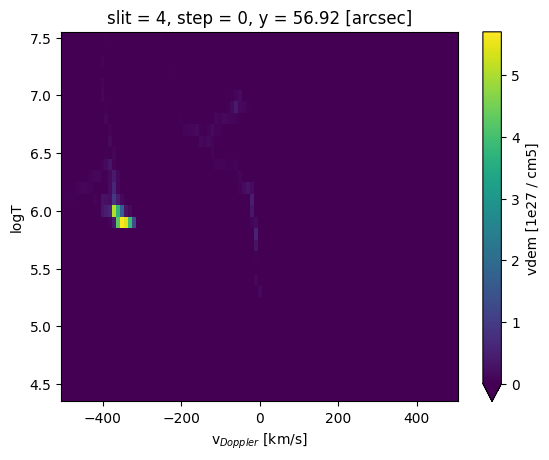

In [313]:
vdem_rs.vdem.sel(y=y, step=step, slit=4, method='nearest').plot(vmin=0)

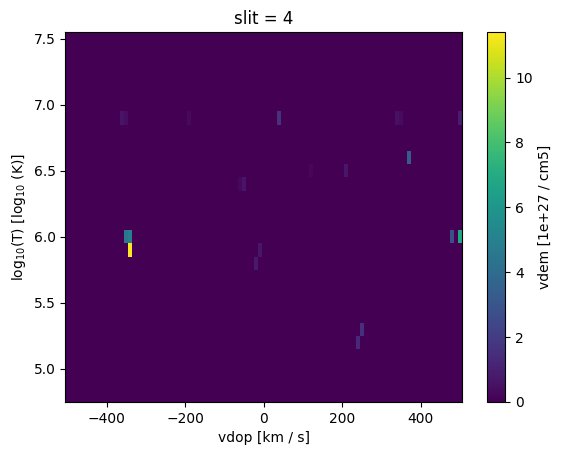

In [308]:
vdem_inv.vdem.isel(slit=4).plot()

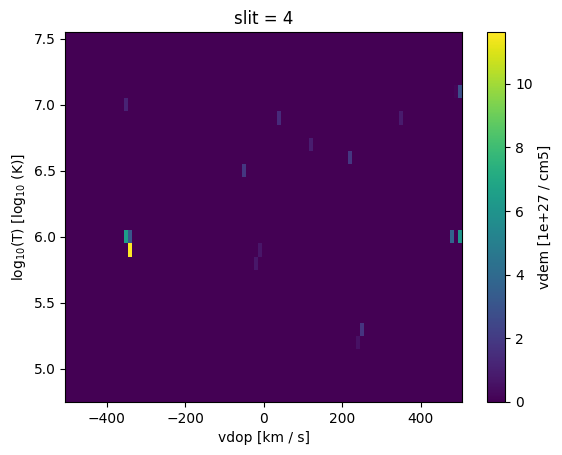

In [318]:
vdem_inv.vdem.isel(slit=4).plot()

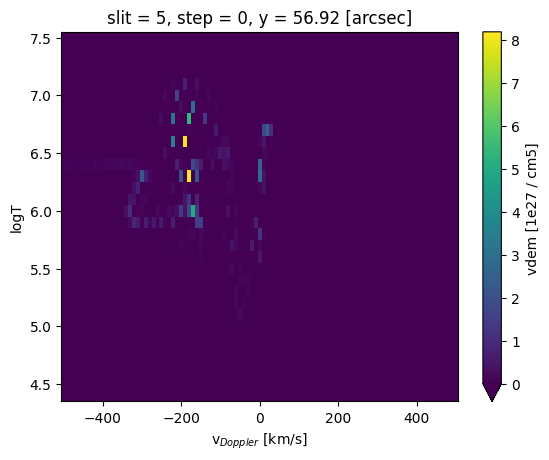

In [314]:
vdem_rs.vdem.sel(y=y, step=step, slit=5, method='nearest').plot(vmin=0)

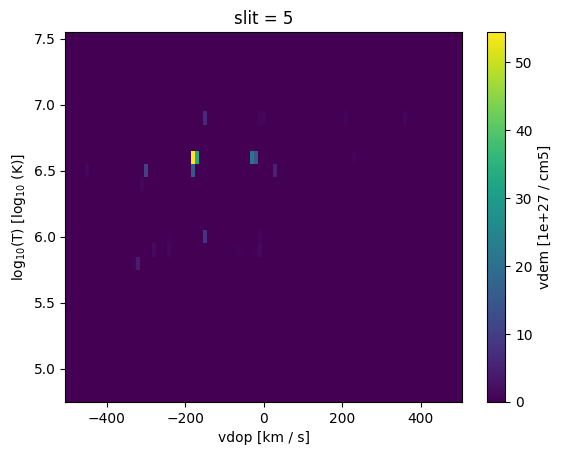

In [315]:
vdem_inv.vdem.isel(slit=5).plot()

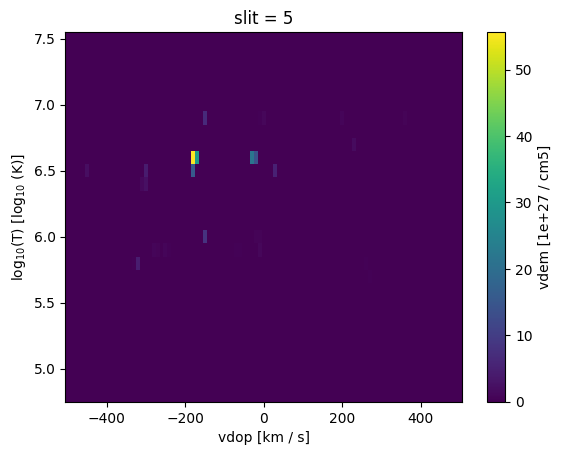

In [319]:
vdem_inv.vdem.isel(slit=5).plot()

In [175]:
from muse.synthesis.synthesis import calc_error
from muse.inversions.inversions import mask_response, vdem_solve
noise0 = calc_error(spec_filled_sample).error
scaling = noise0.max()/noise0
vdem_inv = vdem_solve(
    spec_filled_sample,
    respsum, 
    model=model,
    scaling = scaling, 
    serial = True,
    mask = None,
)

2025-08-18 12:20:24.090 | INFO     | muse.inversions.inversions:vdem_solve:269 - updated shape of R: (3072, 98980)
2025-08-18 12:20:24.091 | INFO     | muse.inversions.inversions:vdem_solve:270 - updated shape of b: (3072, 1)


100%|████████████████████████████████████████████| 1/1 [01:56<00:00, 116.82s/it]

2025-08-18 12:22:34.165 | INFO     | muse.inversions.inversions:vdem_solve:847 - Solve: units of spectrum: DN / s
2025-08-18 12:22:34.167 | INFO     | muse.inversions.inversions:vdem_solve:848 - Solve: units of response: 1e-27 cm5 DN / s
2025-08-18 12:22:34.170 | INFO     | muse.inversions.inversions:vdem_solve:857 - Solve: units of VDEM: 1e+27 / cm5


In [173]:
vdem_inv.failed_vdem.size

98980

In [61]:
mask, maxBnd = mask_response(spec_summed, respsum, return_max=True)

2025-08-14 15:10:04.215 | INFO     | __main__:mask_response:139 - threshold: 2.24 DN
2025-08-14 15:10:04.216 | INFO     | __main__:mask_response:140 - fill_value: 0.5 DN
2025-08-14 15:10:04.217 | INFO     | __main__:mass_screen_wcompile:44 - Using Cuda


ZeroDivisionError: integer division or modulo by zero

In [5]:
with open(base_path+'/output_no_mask.txt', 'w') as file:
    file.write(cap.stdout)

In [6]:
%%capture cap
fill_values = [0.25, 0.5, 0.75, 1]
thresholds = np.round(2.24*np.array([1, 2, 3]), 2)
for fill_value in fill_values:
    for threshold in thresholds:
        print(f"fill_value = {fill_value:.2f}, threshold = {threshold:.2f}")
        save_path = base_path+f'/ddmask1_fill_{fill_value:0.2f}_thres_{threshold:0.2f}'
        try:
            os.mkdir(save_path)
        except:
            pass
        data_driven_mask_keyword={'fill_value':fill_value, 'threshold':threshold}
        output_list_cheating = bench(
            model_path=dpth_vdem_m_flare,
            model_name='muse_vdem_m-flare-muram_los2_trac_fixedvdop_JMS_2May2025_555806.zarr',
            resp_path_sg=dpth_resp+'response_functions_with_slits/',
            resp_path_ci=dpth_resp+'response_functions_CI/',
            FeXIX_108_resp=FeXIX_108_resp,
            FeXXI_108_resp=FeXXI_108_resp,
            contam_108_resp=contam_108_resp,
            FeIX_171_resp=FeIX_171_resp,
            contam_171_resp=contam_171_resp,
            FeXV_284_resp=FeXV_284_resp,
            contam_284_resp=contam_284_resp,
            ci_195_resp=ci_195_resp,
            vdop_inv = np.arange(-400, 410, 10), #controls only Response Functions in the inversions (fixed, no noise exp.)
            velocity_range = 80,
            velocity_range_guided = 400,
            run_SDC=True,
            serial_SDC=False,
            exp_time=0.6,    #noise exp: 0.1,0.6,1.8 s
            # jump_pix = [16, 16], 
            obs_filename_ci=None,
            obs_filename_sg=None,
            gt_filename_sg=None,
            syn_path="./",
            KEYS=['all'],
            line=['Fe IX', 'Fe XV', 'Fe XIX 108.355'],
            intensity_scaling="no_noise",
            model = Lasso(alpha=1e-3, positive=True, fit_intercept=False, max_epochs=500), 
            data_driven_mask_model = mass_screen_gcompile, 
            data_driven_mask_keyword = data_driven_mask_keyword, 
            run_mask = "data_driven", 
            savefigs=True,
            savepath=save_path,
            noise = True,   #noise exp
            save_output = True,
            save_id=f'ddmask1_fill_{fill_value:0.2f}_thres_{threshold:0.2f}', 
            )
        plt.close()


2025-06-06 17:48:14.056 | INFO     | muse.utils.sdc_benchmark:sdc_benchmark:594 - ---------------------------------
2025-06-06 17:48:14.057 | INFO     | muse.utils.sdc_benchmark:sdc_benchmark:595 - LOCAL INPUTS:
2025-06-06 17:48:14.058 | INFO     | muse.utils.sdc_benchmark:sdc_benchmark:599 - model_path : /net/triad/Volumes/Space/MUSE_GCP/muse_vdems/vdems_models/m_flare_muram_trac/
2025-06-06 17:48:14.058 | INFO     | muse.utils.sdc_benchmark:sdc_benchmark:599 - model_name : muse_vdem_m-flare-muram_los2_trac_fixedvdop_JMS_2May2025_555806.zarr
2025-06-06 17:48:14.059 | INFO     | muse.utils.sdc_benchmark:sdc_benchmark:599 - resp_path_sg : /net/triad/Volumes/Space/MUSE_GCP/muse_response_function/Base_line/response_functions_with_slits/
2025-06-06 17:48:14.060 | INFO     | muse.utils.sdc_benchmark:sdc_benchmark:599 - resp_path_ci : /net/triad/Volumes/Space/MUSE_GCP/muse_response_function/Base_line/response_functions_CI/
2025-06-06 17:48:14.061 | INFO     | muse.utils.sdc_benchmark:sdc_ben

In [7]:
with open(base_path+'/output_mask.txt', 'w') as file:
    file.write(cap.stdout)

In [13]:
from io import StringIO

In [14]:
log_stream=StringIO()

In [16]:
log_stream.getvalue()

''

In [21]:
np.sum(np.isnan(output_list_cheating[-1]['all']))/output_list_cheating[-1]['all'].size

<xarray.DataArray 'flux' ()> Size: 8B
array(0.24145508)

In [23]:
(1024-35)/(1024*4)

0.241455078125

In [85]:
1./1402.77*3e5

213.8625719112898